# Develop HTML base

## DGP Representation

The DGP has a Bayes Error Rate of $9.64\%$, and its parameters equation is given by:

$$
 X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	1.0\\
	2.0\\
	-1.0
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	1.0 & 0.2 & 0.2\\
	0.2 & 1.0 & 0.2\\
	0.2 & 0.2 & 1.0
\end{bmatrix}\right), \,X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	0.0\\
	0.0\\
	0.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	1.0 & 0.2 & 0.2\\
	0.2 & 1.0 & 0.2\\
	0.2 & 0.2 & 1.0
\end{bmatrix}\right) 
$$

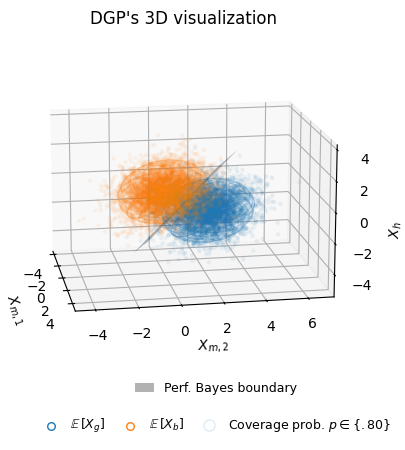

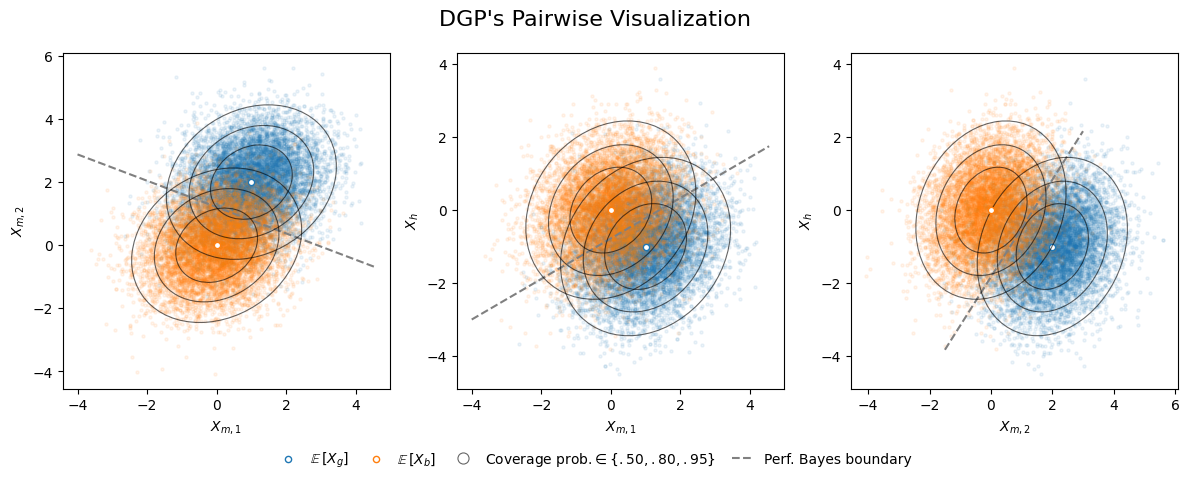

## Expectation comparision

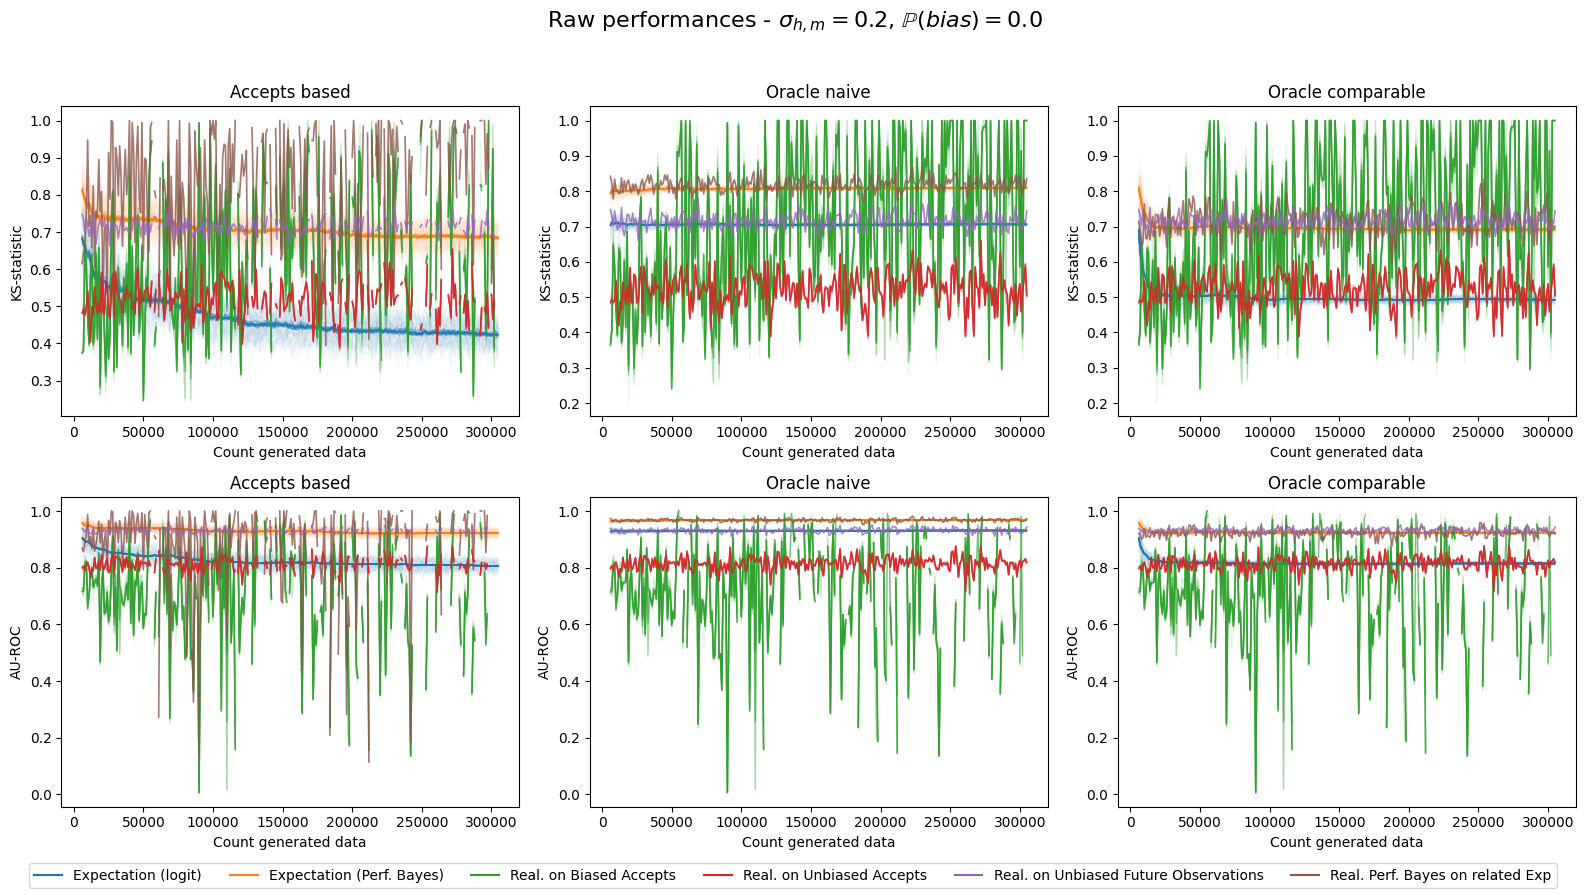

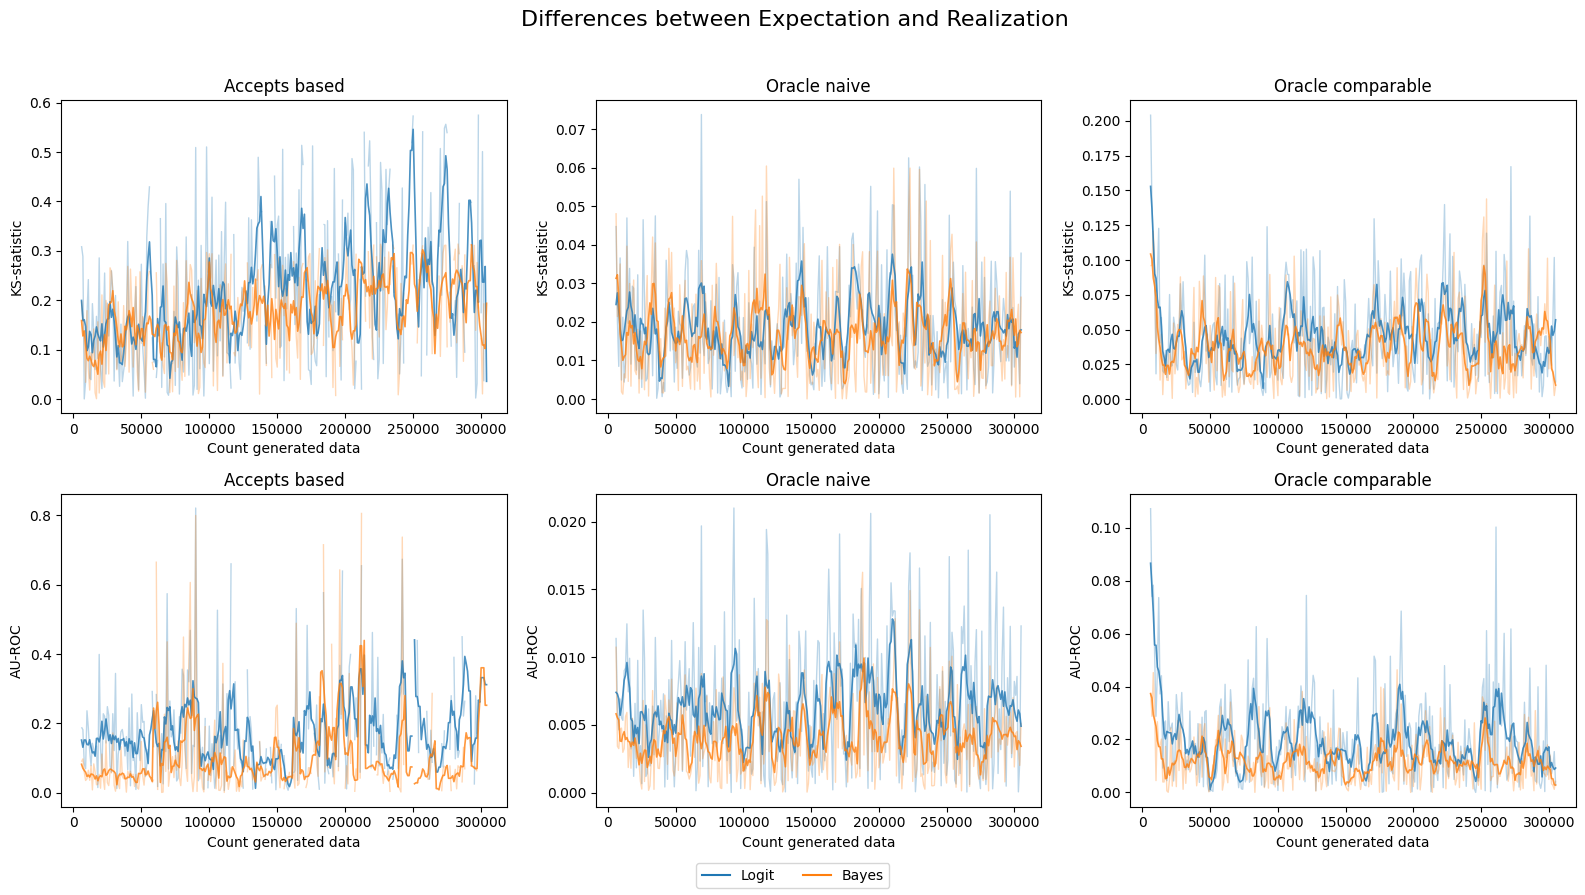

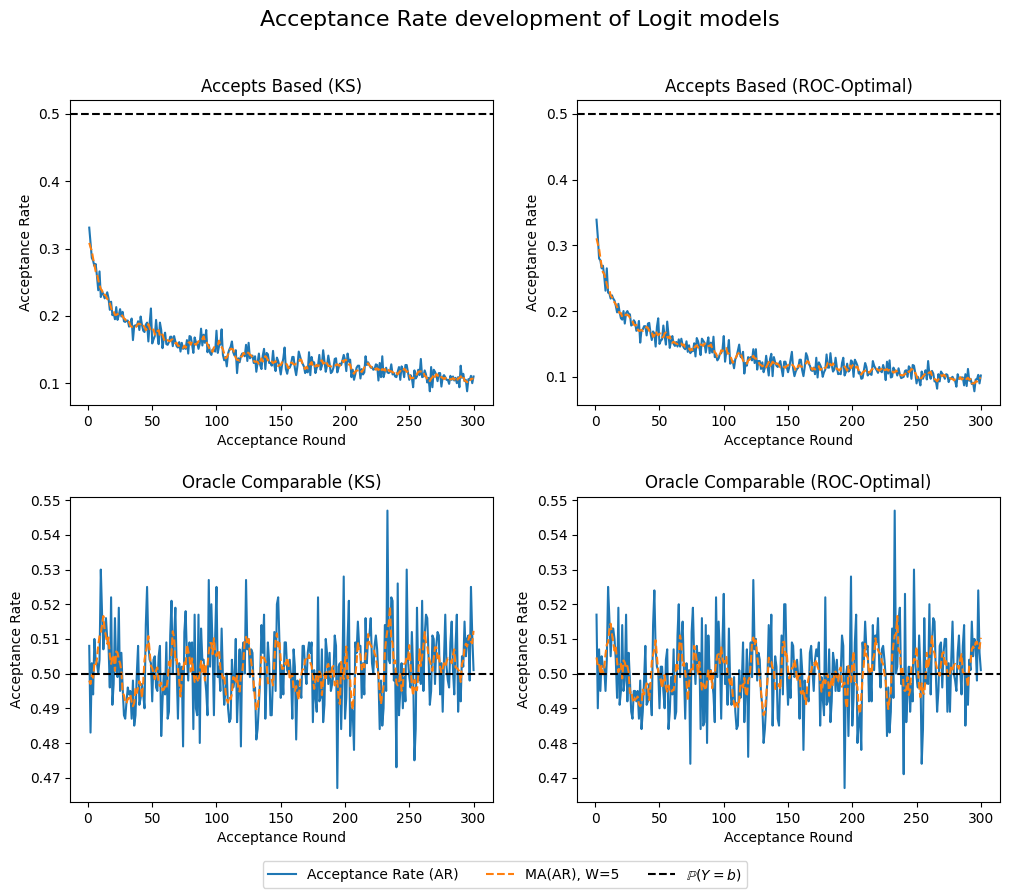

In [ ]:
import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown

from thesis.helper_scripts.dgp_plotting import (
    extract_dgp_info_for_boundaries,
    plot3d_with_perf_bayes_boundary,
    plot_pairwise_dgp_with_perf_bayes_boundaries
)
from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames
from thesis.helper_scripts.hypothesis_visualization import (
    generate_line_collections_for_exp_real_plot,
    plot_lines_and_mains,
    plot_acc_rates_per_round,
    generate_lines_for_diffs,
    gen_lines_from_diff_dict
)

grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
grid_biases = dict(sorted(grid_biases.items(), key=lambda x: x[1]))
grid_corrs = dict(sorted(grid_corrs.items(), key=lambda x: x[1]))
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

# Options containers
## DGP/Simulation selection
bias_options = list(grid_biases.values())
corrs_options = list(grid_corrs.values())
## Absolute performance comparision selection
what_to_show_options = [
    "All",
    "Only Logit on all Realizations",
    "Logit and Bayes on related Realizations"
]
## Line diffs showing
make_abs_options = [True, False]
ma_window_options = list(range(21))

rev_dict_grid_biases = {v : k for k, v in grid_biases.items()}
rev_dict_grid_corrs = {v : k for k, v in grid_corrs.items()}


# These should come from a drop down list each
bias_val = 0.0
corr_val = 0.2
show_option = "All"
selected_make_abs = True
selected_ma_window = 10


sim_objs = all_sim_objs[rev_dict_grid_biases[bias_val]][rev_dict_grid_corrs[corr_val]]

dgp = sim_objs["data_generator"]
dgp_info_for_boundaries = extract_dgp_info_for_boundaries(dgp)
display(Markdown("## DGP Representation"))

bayes_err = dgp.bayes_error_under_equal_covs()
bayes_err_str = f"{bayes_err*100:.2f}"

tex_obj_g, _ = dgp.good_mixture.univariate_mixture_as_tex("g")
text_obj_b, _ = dgp.bad_mixture.univariate_mixture_as_tex("b")

report_str = ("$$\n " + tex_obj_g+
              r", \," + text_obj_b + " \n$$")

display(Markdown(
    "The DGP has a Bayes Error Rate of $" + bayes_err_str + r"\%$, " +
    "and its parameters equation is given by:"
))
display(Markdown(report_str))

plot3d_with_perf_bayes_boundary(
    dgp,
    dgp_info_for_boundaries["W"],
    dgp_info_for_boundaries["bias"],
    title="DGP's 3D visualization"
)
plot_pairwise_dgp_with_perf_bayes_boundaries(
    dgp,
    **dgp_info_for_boundaries,
    fig_title="DGP's Pairwise Visualization"
)

match show_option:
    case "All":
        add_real_bayes, only_related_exp = True, False
    case "Only Logit on all Realizations":
        add_real_bayes, only_related_exp = False, True
    case "Logit and Bayes on related Realizations":
        add_real_bayes, only_related_exp = True, True

display(Markdown("## Expectation comparision"))

plot_lines_and_mains(
    generate_line_collections_for_exp_real_plot(sim_objs, only_related_exp, add_real_bayes),
    sample_sizes=sim_objs["sample_sizes"],
    sup_title="Raw performances - " + sim_objs["Description"],
    add_fig_legend=True,
    add_legend=False,
    only_related_exp=only_related_exp
)

exp_to_real_diffs_base = generate_lines_for_diffs(sim_objs, make_abs=True, W=5)

plot_lines_and_mains(
    gen_lines_from_diff_dict(exp_to_real_diffs_base),
    sample_sizes=exp_to_real_diffs_base["sample_sizes"],
    add_fig_legend=True,
    add_legend=False,
    only_related_exp=True,
    diff_plot=True,
    sup_title="Differences between Expectation and Realization"
)

plot_acc_rates_per_round(sim_objs, fig_title="Acceptance Rate development of Logit models")